In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
state_abbreviations = {
    'Alabama': 'AL',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'Total Us Mulo': 'US',
    'Total Us': 'US',
    'Total US': 'US'
}
# Read the Excel file with multiple sheets
# Replace 'your_file.xlsx' with the path to your actual file
file_path = '/net/dali/home/mscbio/rul98/PheOpt/iRi/FAN FLU states Units all cats.xlsx'
def get_week_start_date(time_str):
    # Extract the date part
    date_part = time_str.replace('1 week ending ', '').replace('Week Ending ', '')
    # Parse the date
    date = pd.to_datetime(date_part)
    # Subtract 6 days to get the week starting date
    week_start_date = date - pd.Timedelta(days=7)
    # Return date in '%Y%m%d' format
    return week_start_date.strftime('%Y%m%d')
# Read all sheets into a dictionary of DataFrames
xls = pd.ExcelFile(file_path)
FAN_sheets = xls.sheet_names  # List of all sheet names
skip = np.append(np.repeat(11, 8), np.repeat(3, 6))
# Loop through each sheet and read data, skipping the metadata rows
FAN_dfs = {}
for s_idx, sheet in enumerate(FAN_sheets):
    FAN_df = pd.read_excel(file_path, sheet_name=sheet, skiprows=skip[s_idx], index_col = None)
    FAN_df.columns = FAN_df.columns.str.replace(' - Multi Outlet', '', regex=False)
    FAN_df.columns = FAN_df.columns.str.replace('State - ', '', regex=False).str.replace(' - MULO', '', regex=False).str.title()
    FAN_df = FAN_df.dropna(axis=0, how = 'all')
    FAN_df['Time'] = FAN_df['Time'].apply(get_week_start_date).astype(int)
    FAN_df = FAN_df.set_index('Time')
    FAN_df.columns = [state_abbreviations[c] for c in FAN_df.columns]
    # print(FAN_df.index[0], FAN_df.index[-1])
    FAN_df = FAN_df[(FAN_df.index >= 20120617) & (FAN_df.index <= 20170312)]
    FAN_df.index = pd.to_datetime(FAN_df.index, format='%Y%m%d')
    FAN_dfs[sheet] = FAN_df
    
# Read the Excel file with multiple sheets
# Replace 'your_file.xlsx' with the path to your actual file
file_path = '/net/dali/home/mscbio/rul98/PheOpt/iRi/illness forecast.xlsx'
# Read all sheets into a dictionary of DataFrames
xls = pd.ExcelFile(file_path)
IF_sheets = xls.sheet_names  # List of all sheet names
skip = np.append(np.repeat(11, 8), np.repeat(3, 6))
# Loop through each sheet and read data, skipping the metadata rows
IF_dfs = {}
for s_idx, sheet in enumerate(IF_sheets):
    IF_df = pd.read_excel(file_path, sheet_name=sheet, skiprows=3, index_col = None)
    IF_df.columns = IF_df.columns.str.replace(' - Multi Outlet', '', regex=False)
    IF_df = IF_df.dropna(axis=0, how = 'all')
    IF_df['Time'] = IF_df['Time'].apply(get_week_start_date).astype(int)
    IF_df = IF_df.set_index('Time')
    IF_df.columns = [state_abbreviations[c] for c in IF_df.columns]
    IF_df = IF_df[(IF_df.index >= 20120617) & (IF_df.index <= 20170312)]
    IF_df.index = pd.to_datetime(IF_df.index, format='%Y%m%d')
    IF_dfs[sheet] = IF_df
dfs = {**FAN_dfs, **IF_dfs}
valid_codes = ['Vitamin C', 'Vit C_IMM', 'Kids Vit C', 'ADCC', 'PDCC', 'ADSA', 'PDSA', 'UR', 'Rfg OJ', 'Hand San', 'Disinfectant',
               'Cough Drops', 'Lip', 'Therm', 'SS BOTTLED APPLE JUICE _ Uni_0', 'SS BOTTLED GRAPE JUICE _ Uni_1', 
               'SS BOTTLED ORANGE JUICE _ Un_2', 'SS BOTTLED TOMATO_VEGETABLE _3', 'COLD_ALLERGY_SINUS LIQUID_PO_4', 
               'COLD_ALLERGY_SINUS TABLETS_P_5', 'FACIAL TISSUE _ Unit Sales', 'COUGH SYRUP _ Unit Sales', 
               'SORE THROAT REMEDY LIQUIDS _11', 'ANTACID LIQUID_POWDER _ Uni_12', 'INTERNAL ANALGESIC LIQUIDS _13', 
               'INTERNAL ANALGESIC TABLETS _14', 'NASAL ASPIRATORS _ Unit Sales', 'NASAL SPRAY_DROPS_INHALER __16', 
               'NASAL STRIPS _ Unit Sales', 'SLEEPING AID LIQUIDS _ Unit_18', 'SLEEPING AID TABLETS _ Unit_19']
valid_dfs = {c: dfs[c] for c in valid_codes}

rename_dict = {
    'Vitamin C': 'Vitamin C Type',
    'Vit C_IMM': 'Vitamin C Immunity Category',
    'Kids Vit C': 'Kids Vitamin C',
    'ADCC': 'Adult Cough Cold Category',
    'PDCC': 'Pediatric Cough Cold Category',
    'ADSA': 'Adult Sinus Allergy Category',
    'PDSA': 'Pediatric Allergy Sinus Category',
    'UR': 'Total Upper Respiratory',
    'Rfg OJ': 'RFG Orange Juice',
    'Hand San': 'Hand Sanitizers',
    'Disinfectant': 'All Purpose Cleaner / Disinfectant',
    'Cough Drops': 'Cough Drops',
    'Lip': 'Lip Treatment',
    'Therm': 'Personal Thermometers',
    'SS BOTTLED APPLE JUICE _ Uni_0': 'Bottled Apple Juice',
    'SS BOTTLED GRAPE JUICE _ Uni_1': 'Bottled Grape Juice',
    'SS BOTTLED ORANGE JUICE _ Un_2': 'Bottled Orange Juice',
    'SS BOTTLED TOMATO_VEGETABLE _3': 'Bottled Tomato Vegetable Juice',
    'COLD_ALLERGY_SINUS LIQUID_PO_4': 'Cold Allergy Sinus Liquid',
    'COLD_ALLERGY_SINUS TABLETS_P_5': 'Cold Allergy Sinus Tablets',
    'FACIAL TISSUE _ Unit Sales': 'Facial Tissue',
    'COUGH SYRUP _ Unit Sales': 'Cough Syrup',
    'SORE THROAT REMEDY LIQUIDS _11': 'Sore Throat Remedy Liquids',
    'ANTACID LIQUID_POWDER _ Uni_12': 'Antacid Liquid / Powder',
    'INTERNAL ANALGESIC LIQUIDS _13': 'Internal Analgesic Liquids',
    'INTERNAL ANALGESIC TABLETS _14': 'Internal Analgesic Tablets',
    'NASAL ASPIRATORS _ Unit Sales': 'Nasal Aspirators',
    'NASAL SPRAY_DROPS_INHALER __16': 'Nasal Spray / Drops / Inhalers',
    'NASAL STRIPS _ Unit Sales': 'Nasal Strips',
    'SLEEPING AID LIQUIDS _ Unit_18': 'Sleeping Aid Liquids',
    'SLEEPING AID TABLETS _ Unit_19': 'Sleeping Aid Tablets'
}
valid_dfs = {rename_dict.get(key, key): dfs[key] for key in valid_codes}
flu_df = pd.read_csv('/net/dali/home/mscbio/rul98/PheOpt/iRi/flu_data_all.csv')[['region', 'epiweek', 'num_ili', 'num_patients', 'wili', 'ili', 'WEEK', 'YEAR', 'State']].drop_duplicates()
flu_df = flu_df.loc[flu_df.YEAR < 2018]
flu_df = flu_df.loc[flu_df.YEAR > 2010]
flu_df = flu_df.groupby(['region', 'epiweek'], as_index=False).last()
flu_df = flu_df.sort_values(by=['region', 'YEAR', 'WEEK'])
flu_df = flu_df.dropna(subset=['State'])
flu_df['Time'] = pd.to_datetime(flu_df['epiweek'], format='%m/%d/%y')
epiweek = flu_df[['YEAR', 'WEEK', 'Time']].drop_duplicates().reset_index(drop = True)
flu_pivot = flu_df.pivot_table(values='ili', index='Time', columns='region')
valid_dfs['ili'] = flu_pivot

In [3]:
target_name = 'ili'
target_wide = valid_dfs[target_name]
all_signal_wides = {}
for name in ['Vitamin C Type', 'Vitamin C Immunity Category', 'Kids Vitamin C', 'Adult Cough Cold Category', 'Pediatric Cough Cold Category', 'Adult Sinus Allergy Category', 'Pediatric Allergy Sinus Category', 'Total Upper Respiratory', 'RFG Orange Juice', 'Hand Sanitizers', 'All Purpose Cleaner / Disinfectant', 'Cough Drops', 'Lip Treatment', 'Personal Thermometers', 'Bottled Apple Juice', 'Bottled Grape Juice', 'Bottled Orange Juice', 'Bottled Tomato Vegetable Juice', 'Cold Allergy Sinus Liquid', 'Cold Allergy Sinus Tablets', 'Facial Tissue', 'Cough Syrup', 'Sore Throat Remedy Liquids', 'Antacid Liquid / Powder', 'Internal Analgesic Liquids', 'Internal Analgesic Tablets', 'Nasal Aspirators', 'Nasal Spray / Drops / Inhalers', 'Nasal Strips', 'Sleeping Aid Liquids', 'Sleeping Aid Tablets']:
    all_signal_wides[name] = valid_dfs[name]

VALID_STATES = ['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'NC', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

In [4]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
import celer

# =========================
# Aggregation: sparsity index candidate states + Q-aggregation on validation
# =========================
def estimate_R_hat_from_series(d0, dl, s: int):
    """
    Robust: handles pd.Series (preferred) and numpy arrays (fallback).
    If both are Series: align by feature names (intersection).
    Otherwise: align by common prefix length.
    """
    # Case 1: both are Series => align by feature name
    if hasattr(d0, "index") and hasattr(dl, "index"):
        common = d0.index.intersection(dl.index)
        if len(common) == 0:
            return np.inf
        Delta = (dl.loc[common] - d0.loc[common]).to_numpy()
        m = len(Delta)
    else:
        # Case 2: fallback to positional alignment
        d0 = np.asarray(d0, float).ravel()
        dl = np.asarray(dl, float).ravel()
        m = min(len(d0), len(dl))
        if m == 0:
            return np.inf
        Delta = dl[:m] - d0[:m]

    s = int(min(s, m))
    if s <= 0:
        return 0.0
    idx = np.argpartition(np.abs(Delta), -s)[-s:]
    return float(np.sum(Delta[idx] ** 2))

def select_candidate_states(d_by_state, target_state, all_states, s=300, K=10):
    d0 = d_by_state[target_state]
    scores = []
    for st in all_states:
        if st == target_state:
            continue
        if st not in d_by_state:
            continue
        R = estimate_R_hat_from_series(d0, d_by_state[st], s=s)
        scores.append((st, R))
    scores.sort(key=lambda x: x[1])
    return [st for st, _ in scores[:K]]

def q_aggregate_weights(y_val, Yhat_val, total_step=10, selection=False, eps=1e-3):
    """
    Q-aggregation in prediction space.

    Inputs
    ------
    y_val      : (n,) or (n,1) target validation outcomes
    Yhat_val   : (n, M) candidate predictions on validation set
    total_step : max iterations
    selection  : if True, pick single best candidate (one-hot weights)
    eps        : stopping tolerance on L1 change in weights

    Returns
    -------
    theta_hat  : (M,) weights on simplex
    """
    y = np.asarray(y_val, float).reshape(-1, 1)
    XB = np.asarray(Yhat_val, float)  # (n, M)
    n, M = XB.shape

    if M == 0:
        return np.array([], dtype=float)
    if M == 1:
        return np.array([1.0], dtype=float)

    # selection option: pick candidate with smallest MSE on validation
    if selection:
        mse = np.mean((y - XB) ** 2, axis=0)
        khat = int(np.argmin(mse))
        theta_hat = np.zeros(M, dtype=float)
        theta_hat[khat] = 1.0
        return theta_hat

    # initialize weights proportional to exp(-RSS/2)
    rss = np.sum((y - XB) ** 2, axis=0)  # (M,)
    # numerical stability
    a = -0.5 * rss
    a = a - np.max(a)
    theta_hat = np.exp(a)
    theta_hat /= theta_hat.sum()

    theta_old = theta_hat.copy()

    # initialize aggregated prediction
    beta_pred = XB @ theta_hat  # (n,)

    for _ in range(int(total_step)):
        Xbeta = beta_pred.reshape(-1, 1)  # (n,1)

        # theta <- exp(-RSS/2 + ||Xbeta - XB||^2 / 8)
        adj = np.sum((Xbeta - XB) ** 2, axis=0) / 8.0
        a = -0.5 * rss + adj
        a = a - np.max(a)  # stabilize
        theta_hat = np.exp(a)
        theta_hat /= theta_hat.sum()

        # beta <- 1/4 * (XB theta) + 3/4 * beta
        beta_new = (XB @ theta_hat) * 0.25 + 0.75 * beta_pred

        # stopping
        if np.sum(np.abs(theta_hat - theta_old)) < eps:
            beta_pred = beta_new
            break

        theta_old = theta_hat.copy()
        beta_pred = beta_new

    return theta_hat



# =========================
# Dataset construction
# =========================
def build_design_for_state(
    target_wide: pd.DataFrame,
    feature_wides: dict,
    state: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    feature_lags,
    ar_lags,
    unit
):
    """
    Build X,y for ONE state in [start_date, end_date] inclusive.
    X columns:
      - for each feature signal: values lagged by feature_lags (group = signal)
      - for target signal: AR lags by ar_lags (group = 'AR')
    Returns (X, y, dates, feature_names, group_names).
    """

    max_lag = max(max(feature_lags), max(ar_lags))
    start_ext = start_date - pd.Timedelta(max_lag, unit = unit)

    # base index
    idx = target_wide.loc[start_ext:end_date].index

    y_series = target_wide.loc[idx, state].copy()

    X_blocks = []
    feature_names = []
    group_names = []

    # exogenous features
    for sig_name, wide in feature_wides.items():
        if state not in wide.columns:
            continue
        s = wide.loc[idx, state].copy()
        for lag in feature_lags:
            X_blocks.append(s.shift(lag))
            feature_names.append(f"{sig_name}_lag{lag}")
        group_names.append(sig_name)

    # AR features (target lags)
    for lag in ar_lags:
        X_blocks.append(y_series.shift(lag))
        feature_names.append(f"AR_lag{lag}")
    group_names.append("AR")

    X_df = pd.concat(X_blocks, axis=1)
    X_df.columns = feature_names

    # keep only rows within [start_date, end_date] after shifting
    aligned = pd.concat([y_series.rename("y"), X_df], axis=1)
    aligned = aligned.loc[start_date:end_date].dropna()

    if len(aligned) == 0:
        return None

    y = aligned["y"].values.astype(float)
    X = aligned.drop(columns=["y"]).values.astype(float)
    dates = aligned.index

    return X, y, dates, feature_names, group_names


def compute_walkforward_schedule(dates, train_size, test_size, retrain_every, unit = 'd'):
    """
    Create monthly retraining points (train_end) so that:
      test_end = train_end + test_size is within data range
    train_end moves forward by retrain_every.
    """
    dates = pd.to_datetime(dates).sort_values()
    start = dates.min() + pd.Timedelta(train_size, unit)
    end = dates.max() - pd.Timedelta(test_size, unit)

    if start >= end:
        return []

    start = dates[dates.get_indexer([start], method="nearest")[0]]
    train_ends = []
    cur = start
    while cur <= end:
        train_ends.append(cur)
        cur = cur + pd.Timedelta(retrain_every, unit = unit)
    return train_ends

# =========================
# GroupLasso utilities (SIS + KKT)
# (mostly matching your earlier code; assumes equal group_size)
# =========================
def extend_indices(g_indices, group_size):
    g_indices = np.asarray(g_indices, dtype=int)
    v = (g_indices[:, None] * group_size + np.arange(group_size)[None, :]).ravel()
    return v.astype(int)

def shrink_indices(v_indices, group_size):
    v_indices = np.asarray(v_indices, dtype=int)
    return np.unique(v_indices // group_size).astype(int)

def standardize_xy(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=0)
    X_std[X_std == 0] = 1.0
    Xz = (X - X_mean) / X_std

    y_mean = y.mean()
    y_std = y.std(ddof=0)
    if y_std == 0:
        y_std = 1.0
    yz = (y - y_mean) / y_std
    return Xz, yz, X_mean, X_std, y_mean, y_std

def recover_coefficients(unit_coef, X_std, y_std):
    X_std = np.asarray(X_std, dtype=float)
    return (y_std / X_std) * unit_coef

def recover_intercept(X, y, coef_original, X_mean=None, y_mean=None):
    if X_mean is None:
        X_mean = np.mean(X, axis=0)
    if y_mean is None:
        y_mean = np.mean(y)
    return float(y_mean - X_mean.dot(coef_original))

def SIS(X, y, nSel):
    X = np.asarray(X)
    y = np.asarray(y)

    y_std = y.std()
    if y_std == 0:
        return np.array([], dtype=int)

    corrs = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        xj = X[:, j]
        sx = xj.std()
        if sx == 0:
            corrs[j] = 0.0
        else:
            corrs[j] = abs(np.cov(xj, y, bias=True)[0, 1] / (sx * y_std))

    order = np.argsort(corrs)[::-1]
    return order[:nSel].astype(int)

def fit_grpLasso(Xz, yz, alpha, group_size, weights=None):
    model = celer.GroupLasso(
        groups=group_size,           # equal block size
        alpha=alpha,
        tol=1e-4,
        fit_intercept=False,
        weights=weights
    )
    model.fit(Xz, yz)
    return model, model.coef_.copy()

def check_KKT(Xz, yz, coef_unit_full, active_g_indices, group_size, alpha, weights=None, tol=1e-4):
    residual = yz - Xz.dot(coef_unit_full)
    p_groups = Xz.shape[1] // group_size
    stats = np.zeros(p_groups)

    for g in range(p_groups):
        j0 = g * group_size
        j1 = j0 + group_size
        Xg = Xz[:, j0:j1]
        stats[g] = np.linalg.norm(Xg.T.dot(residual), 2) / Xg.shape[0]

    thresh = alpha if weights is None else alpha * np.asarray(weights)
    violated = np.where(stats > (thresh + tol))[0]
    violated = list(set(violated) - set(np.asarray(active_g_indices, dtype=int)))
    violated.sort()
    return violated

def SIS_grpLasso_KKT(X_expanded, y, group_size, alpha, weights=None, sis_ratio=1.0, max_iter=50):
    n, p_exp = X_expanded.shape
    p_groups = p_exp // group_size

    Xz, yz, X_mean, X_std, y_mean, y_std = standardize_xy(X_expanded, y)

    # Always define this, even if SIS selects nothing
    coef_unit_full = np.zeros(p_exp, dtype=float)

    # fast group summary for SIS: RMS within each group
    X3 = Xz.reshape(n, p_groups, group_size)
    X_group = np.sqrt(np.mean(X3**2, axis=2))

    nSel = int(max(1, min(p_groups, np.floor((len(y) / group_size - 1) * sis_ratio))))
    violated_g = list(SIS(X_group, yz, nSel=nSel))

    # If SIS selects nothing, return intercept-only model
    if len(violated_g) == 0:
        coef = recover_coefficients(coef_unit_full, X_std, y_std)  # all zeros
        intercept = float(y_mean)  # y_mean - X_mean@0
        return np.array([], dtype=int), coef, intercept

    active_g = np.array([], dtype=int)

    it = 0
    while len(violated_g) > 0:
        it += 1
        if it > max_iter:
            break

        active_g = np.array(sorted(set(active_g) | set(violated_g)), dtype=int)
        SIS_v = extend_indices(active_g, group_size)

        _, coef_unit_sub = fit_grpLasso(
            Xz[:, SIS_v], yz, alpha=alpha, group_size=group_size, weights=weights
        )

        coef_unit_full[:] = 0.0
        coef_unit_full[SIS_v] = coef_unit_sub

        violated_g = check_KKT(
            Xz, yz, coef_unit_full, active_g, group_size, alpha, weights=weights
        )

    coef = recover_coefficients(coef_unit_full, X_std, y_std)
    intercept = recover_intercept(X_expanded, y, coef, X_mean=X_mean, y_mean=y_mean)

    active_v = np.where(coef != 0)[0]
    active_g_final = shrink_indices(active_v, group_size)
    return active_g_final, coef, intercept



# =========================
# Baseline: AR-only with exp-decay weights (choose gamma by validation)
# =========================
def weighted_ols_fit_predict(X_train, y_train, w_train, X_pred):
    X_train = np.asarray(X_train, float)
    y_train = np.asarray(y_train, float)
    w_train = np.asarray(w_train, float)
    X_pred  = np.asarray(X_pred,  float)

    Xtr = np.column_stack([np.ones(len(X_train)), X_train])
    Xpr = np.column_stack([np.ones(len(X_pred)),  X_pred])

    sw = np.sqrt(np.clip(w_train, 0.0, np.inf))
    Xw = Xtr * sw[:, None]
    yw = y_train * sw

    eps = 1e-8
    A = Xw.T @ Xw + eps * np.eye(Xw.shape[1])
    b = Xw.T @ yw
    beta = np.linalg.solve(A, b)
    return Xpr @ beta

def fit_ar_baseline_decay(X_train, y_train, X_val, y_val, train_dates, train_end, gammas):
    """
    Choose gamma that minimizes val MSE.
    train_dates: DatetimeIndex aligned with X_train/y_train rows
    train_end: Timestamp = last day in training window
    """
    train_end = pd.to_datetime(train_end)
    backcast_lag = (train_end - pd.to_datetime(train_dates)).days.astype(float).values

    best = None
    for g in gammas:
        w = np.exp(-g * backcast_lag)
        w = w / (w.max() if w.max() > 0 else 1.0)
        yhat_val = weighted_ols_fit_predict(X_train, y_train, w, X_val)
        mse = mean_squared_error(y_val, yhat_val)
        if best is None or mse < best["mse"]:
            best = {"gamma": g, "mse": mse}
    return best["gamma"]

def predict_named(X, feat_names_ref, coef_series, intercept):
    w = coef_series.reindex(feat_names_ref).fillna(0.0).to_numpy()
    return X @ w + intercept

5


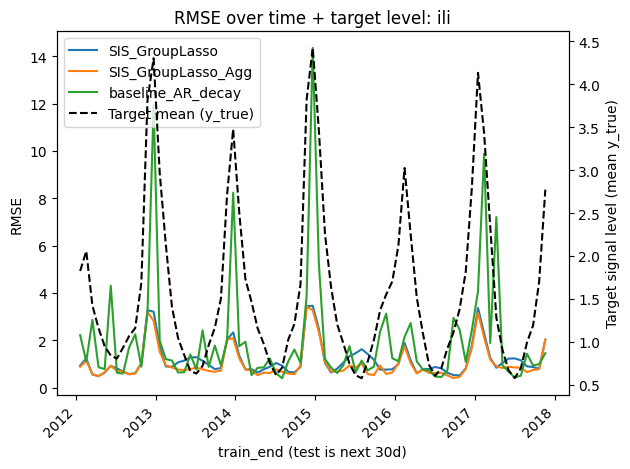

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.392142  0.900175  15708.0
1           ili  SIS_GroupLasso_Agg  1.250821  0.763177  15708.0
2           ili   baseline_AR_decay  3.212695  1.094436  15708.0


In [8]:
FEATURE_LAGS = (1, 2, 3, 4)
AR_LAGS      = (1, 2, 3, 4)
BASELINE_GAMMAS = [0.0, 0.01, 0.05, 0.1]
K_CANDIDATES = 3
S_SCREEN = 50    # top-s entries in sparsity-index screening
unit = 'W'
RETRAIN_EVERY = 4
TEST_WINDOW = 4
VAL_WINDOW = 4
TRAIN_WINDOW = 55

target_wide = target_wide.sort_index()
target_idx = pd.to_datetime(target_wide.index)
feature_wides_raw = {k: v for k, v in all_signal_wides.items() if k != target_name}
feature_wides = {}
for sig_name, wide in feature_wides_raw.items():
    if wide is None or len(wide) == 0:
        continue
    wide = wide.sort_index().copy()
    wide.index = pd.to_datetime(wide.index)
    wide_aligned = wide.reindex(target_idx)
    wide_aligned = wide_aligned.mask(wide_aligned < 0, 0.0)
    # wide_aligned = wide_aligned.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
    # wide_aligned = wide_aligned.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
    wide_aligned = wide_aligned.fillna(0.0)
    nonconstant_cols = (wide_aligned.abs().sum(axis=0) > 0)
    wide_aligned = wide_aligned.loc[:, nonconstant_cols]
    if wide_aligned.shape[1] == 0:
        continue
    feature_wides[sig_name] = wide_aligned

# Determine states common across target + (at least some) features
states = [c for c in target_wide.columns if c.isalpha() and len(c) == 2]  # typical state abbrev
states = [st for st in states if st in target_wide.columns]
if len(states) == 0:
    states = list(target_wide.columns)

train_ends = compute_walkforward_schedule(dates = target_wide.index, train_size = TRAIN_WINDOW, test_size = TEST_WINDOW, retrain_every = RETRAIN_EVERY, unit = unit)

group_size = len(FEATURE_LAGS)
assert len(AR_LAGS) == group_size, "AR_LAGS must have same length as FEATURE_LAGS for equal-size groups."

for GL_ALPHA in [0.1, 0.5, 1, 5]:
    pred_rows = []
    agg_rows = []
    for train_end in train_ends:
        train_end = pd.to_datetime(train_end)
        train_start = train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = unit)
        val_start = train_end - pd.Timedelta(VAL_WINDOW - 1, unit = unit)
        test_start = train_end + pd.Timedelta(1, unit = unit)
        test_end = train_end + pd.Timedelta(TEST_WINDOW, unit = unit)

        # Fit GroupLasso for ALL states in this window (target-only training per state)
        # Store coefs/intercepts and d = X^T y / T for candidate selection
        fit_by_state = {}
        d_by_state = {}

        # also store AR-only baseline (gamma chosen per state)
        baseline_by_state = {}

        # Pre-build datasets per state (train/val/test)
        data_cache = {}

        for st in states:
            # build full window design up to test_end so we can slice train/val/test cleanly
            built = build_design_for_state(
                target_wide, feature_wides, st,
                start_date=train_start, end_date=test_end,
                feature_lags=FEATURE_LAGS, ar_lags=AR_LAGS, unit = unit
            )
            if built is None:
                continue
            X_all, y_all, dates_all, feat_names, group_names = built
            data_cache[st] = (X_all, y_all, dates_all, feat_names, group_names)

            # indices for train/val/test within aligned dates_all
            dates_all = pd.to_datetime(dates_all)
            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)

            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ---------- Baseline: AR-only with decay gamma tuned on val ----------
            # AR columns are last len(AR_LAGS) columns by construction
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]
            best_gamma = fit_ar_baseline_decay(
                Xtr_ar, y_tr, Xva_ar, y_va, train_dates=d_tr, train_end=train_end, gammas=BASELINE_GAMMAS
            )
            baseline_by_state[st] = {"gamma": best_gamma}

            # ---------- SIS-GroupLasso fit ----------
            active_g, coef, intercept = SIS_grpLasso_KKT(
                X_expanded=X_tr, y=y_tr,
                group_size=group_size, alpha=GL_ALPHA, weights=None
            )
            fit_by_state[st] = {
                "coef": pd.Series(coef, index=feat_names),
                "intercept": intercept,
                "active_g": active_g
            }

            # d statistic for candidate selection (use training)
            d_by_state[st] = (X_tr.T @ y_tr) / max(len(y_tr), 1)

        if len(fit_by_state) < 2:
            continue

        # Now evaluate per state
        for st in list(fit_by_state.keys()):
            X_all, y_all, dates_all, feat_names, group_names = data_cache[st]
            dates_all = pd.to_datetime(dates_all)

            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)
            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ----- Baseline predictions -----
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]

            g = baseline_by_state[st]["gamma"]
            backcast_lag = (train_end - d_tr).days.astype(float).values
            w = np.exp(-g * backcast_lag)
            w = w / (w.max() if w.max() > 0 else 1.0)
            yhat_base = weighted_ols_fit_predict(Xtr_ar, y_tr, w, Xte_ar)

            # ----- SIS-GroupLasso target-only predictions -----
            target_feat_names = feat_names
            fit0 = fit_by_state[st]
            yhat_gl = predict_named(X_te, target_feat_names, fit0["coef"], fit0["intercept"])

            # ----- Aggregation -----
            # candidate states via sparsity index
            # all_states_here = [s for s in fit_by_state.keys() if s in d_by_state]
            all_states_here = [s for s in fit_by_state.keys() if s in d_by_state and s in VALID_STATES]
            cand_states = select_candidate_states(d_by_state, st, all_states_here, s=S_SCREEN, K=K_CANDIDATES)
            cand_all = [st] + cand_states

            # build Yhat on validation (on target state's X_va) and test (on target state's X_te)
            Yhat_val = []
            Yhat_test = []
            for s2 in cand_all:
                fit2 = fit_by_state[s2]
                Yhat_val.append(predict_named(X_va, target_feat_names, fit2["coef"], fit2["intercept"]))
                Yhat_test.append(predict_named(X_te, target_feat_names, fit2["coef"], fit2["intercept"]))
            Yhat_val = np.column_stack(Yhat_val)
            Yhat_test = np.column_stack(Yhat_test)

            w_agg = q_aggregate_weights(y_va, Yhat_val, total_step=10, selection=False, eps=1e-3)
            yhat_agg = Yhat_test @ w_agg
            for j, s2 in enumerate(cand_all):
                agg_rows.append({
                    "target_signal": target_name,
                    "target_state": st,
                    "train_end": train_end.date().isoformat(),
                    "candidate_state": s2,
                    "is_self": (j == 0),
                    "rank": j,                 # 0=self, 1..K are candidates
                    "weight": float(w_agg[j])  # weight for this candidate in Q-agg
                })
            for i, dt in enumerate(d_te):
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "baseline_AR_decay",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_base[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_gl[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso_Agg",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_agg[i]),
                })
    print(GL_ALPHA)
    pred_df = pd.DataFrame(pred_rows)
    agg_df = pd.DataFrame(agg_rows)
    agg_df["train_end"] = pd.to_datetime(agg_df["train_end"])
    # summary metrics
    summary = (
        pred_df.groupby(["target_signal", "model", "geo_value"])
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "N": len(g)
        }))
        .reset_index()
    )

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
    pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

    def rmse(x):
        return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))

    # A) RMSE per retrain step (each step = next 30-day test period)
    rmse_by_step = (
        pred_df
        .groupby(["target_signal", "model", "train_end"])
        .apply(rmse)
        .rename("RMSE")
        .reset_index()
        .sort_values(["target_signal", "model", "train_end"])
    )

    sig = pred_df["target_signal"].iloc[0]
    tmp = rmse_by_step[rmse_by_step["target_signal"] == sig].copy()

    # Build a "target level" series aligned to train_end:
    # use mean(y_true) over the corresponding test block (all states pooled)
    target_level = (
        pred_df[pred_df["target_signal"] == sig]
        .groupby("train_end")["y_true"]
        .mean()
        .rename("target_mean")
        .reset_index()
    )

    # Merge so x-axis aligns
    tmp2 = tmp.merge(target_level, on="train_end", how="left")

    fig, ax = plt.subplots()

    # left axis: RMSE by model
    for m, g in tmp2.groupby("model"):
        ax.plot(g["train_end"], g["RMSE"], label=m)
    ax.set_xlabel("train_end (test is next 30d)")
    ax.set_ylabel("RMSE")

    # right axis: target signal level
    ax2 = ax.twinx()
    ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
    ax2.set_ylabel("Target signal level (mean y_true)")

    # combined legend (both axes)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax.set_title(f"RMSE over time + target level: {sig}")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


    print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    })).reset_index())

    # exclude self
    cand_only = agg_df[~agg_df["is_self"]].copy()

    # frequency table
    freq = (
        cand_only
        .groupby(["target_signal", "target_state", "candidate_state"])
        .size()
        .rename("count")
        .reset_index()
    )

    from collections import defaultdict

    def most_frequent_candidates_dict(agg_df, top_k=5, drop_self=True, min_count=1):
        df = agg_df.copy()

        if drop_self and "is_self" in df.columns:
            df = df[~df["is_self"]]

        # frequency count
        freq = (
            df.groupby(["target_state", "candidate_state"])
            .size()
            .rename("count")
            .reset_index()
        )

        # filter low counts if wanted
        freq = freq[freq["count"] >= min_count]

        # build dict: state -> list of top_k candidates
        out = {}
        for st, g in freq.sort_values(["target_state", "count"], ascending=[True, False]).groupby("target_state"):
            out[st] = g["candidate_state"].head(top_k).tolist()

        return out

    # usage:
    top_candidates = most_frequent_candidates_dict(agg_df, top_k=5)
    top_candidates

/tmp/ipykernel_823123/2968602586.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


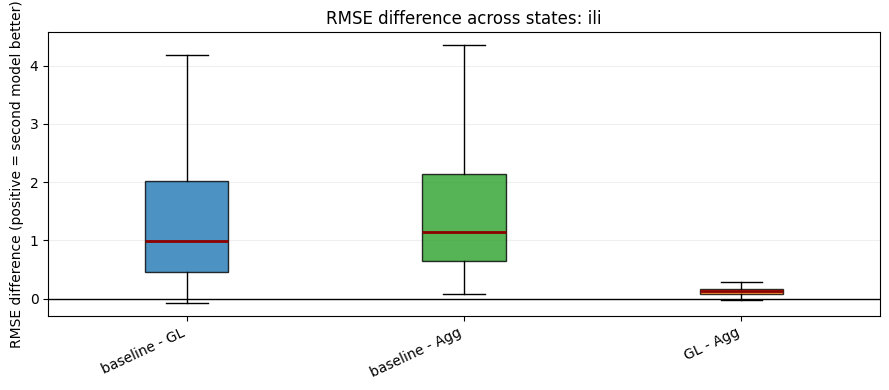

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sig = pred_df["target_signal"].iloc[0]
df_sig = pred_df[pred_df["target_signal"] == sig].copy()

# per-state RMSE for each model (across ALL test points in pred_df)
rmse_state = (
    df_sig.groupby(["geo_value", "model"])
    .apply(lambda g: np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
    .rename("RMSE")
    .reset_index()
)

# wide: rows=state, cols=model
rmse_wide = rmse_state.pivot(index="geo_value", columns="model", values="RMSE")

# choose your model names
BASE = "baseline_AR_decay"
GL   = "SIS_GroupLasso"
AGG  = "SIS_GroupLasso_Agg"

# keep only states with all models present
rmse_wide = rmse_wide[[BASE, GL, AGG]].dropna()

# differences (positive means SECOND is better if you do base - other? depends)
diff_df = pd.DataFrame(index=rmse_wide.index)
diff_df["baseline - GL"]  = rmse_wide[BASE] - rmse_wide[GL]
diff_df["baseline - Agg"] = rmse_wide[BASE] - rmse_wide[AGG]
diff_df["GL - Agg"]       = rmse_wide[GL]   - rmse_wide[AGG]

def get_base_diff(colname: str):
    # here each column is already a base diff label
    return colname

base_diff_to_color = {
    "baseline - GL":  "tab:blue",
    "baseline - Agg": "tab:green",
    "GL - Agg":       "tab:orange",
}

def color_boxes_by_diff(ax, bp, columns):
    for i, box_artist in enumerate(bp["boxes"]):
        colname = columns[i]
        color = base_diff_to_color.get(colname, "lightgray")
        box_artist.set_facecolor(color)
        box_artist.set_edgecolor("black")
        box_artist.set_alpha(0.8)

    for w in bp["whiskers"]:
        w.set(color="black", linewidth=1)
    for c in bp["caps"]:
        c.set(color="black", linewidth=1)
    for m in bp["medians"]:
        m.set(color="darkred", linewidth=2)

# Plot
cols = diff_df.columns.tolist()

fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    [diff_df[c].values for c in cols],
    labels=cols,
    patch_artist=True,
    showfliers=False
)

color_boxes_by_diff(ax, bp, cols)

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("RMSE difference (positive = second model better)")
ax.set_title(f"RMSE difference across states: {sig}")
ax.grid(True, axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


0.1


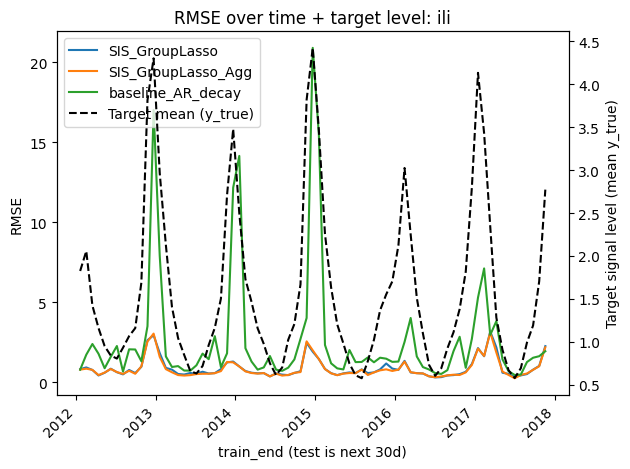

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.091133  0.603811  15708.0
1           ili  SIS_GroupLasso_Agg  1.061587  0.586109  15708.0
2           ili   baseline_AR_decay  4.666725  1.497614  15708.0
0.5


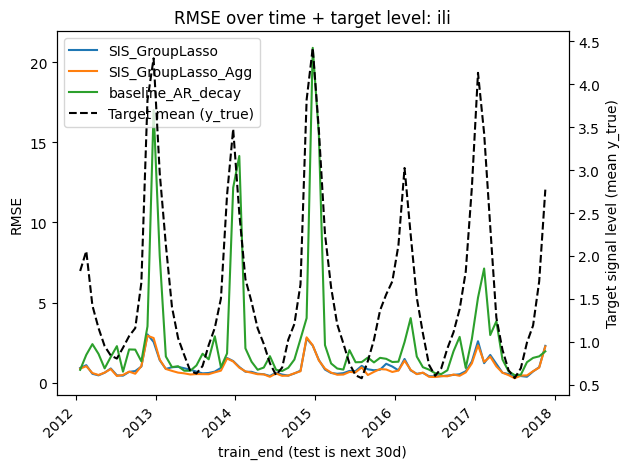

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.074252  0.631655  15708.0
1           ili  SIS_GroupLasso_Agg  1.030225  0.585021  15708.0
2           ili   baseline_AR_decay  4.666725  1.497614  15708.0
1


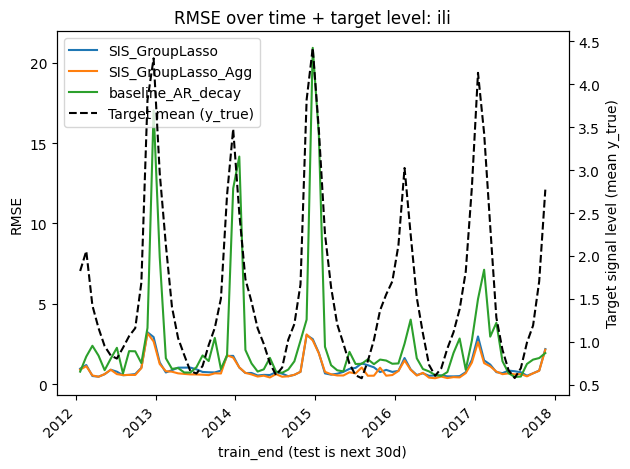

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.196882  0.734080  15708.0
1           ili  SIS_GroupLasso_Agg  1.102310  0.642255  15708.0
2           ili   baseline_AR_decay  4.666725  1.497614  15708.0
5


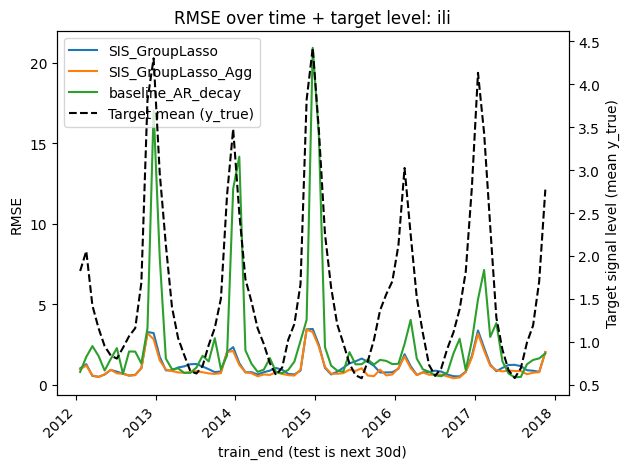

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.393305  0.901470  15708.0
1           ili  SIS_GroupLasso_Agg  1.252212  0.764316  15708.0
2           ili   baseline_AR_decay  4.666725  1.497614  15708.0


In [6]:
FEATURE_LAGS = (1, 2, 3, 4)
AR_LAGS      = (3, 4, 5, 6)
BASELINE_GAMMAS = [0.0, 0.01, 0.05, 0.1]
K_CANDIDATES = 3
S_SCREEN = 50    # top-s entries in sparsity-index screening
unit = 'W'
RETRAIN_EVERY = 4
TEST_WINDOW = 4
VAL_WINDOW = 4
TRAIN_WINDOW = 55

target_wide = target_wide.sort_index()
target_idx = pd.to_datetime(target_wide.index)
feature_wides_raw = {k: v for k, v in all_signal_wides.items() if k != target_name}
feature_wides = {}
for sig_name, wide in feature_wides_raw.items():
    if wide is None or len(wide) == 0:
        continue
    wide = wide.sort_index().copy()
    wide.index = pd.to_datetime(wide.index)
    wide_aligned = wide.reindex(target_idx)
    wide_aligned = wide_aligned.mask(wide_aligned < 0, 0.0)
    # wide_aligned = wide_aligned.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
    # wide_aligned = wide_aligned.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
    wide_aligned = wide_aligned.fillna(0.0)
    nonconstant_cols = (wide_aligned.abs().sum(axis=0) > 0)
    wide_aligned = wide_aligned.loc[:, nonconstant_cols]
    if wide_aligned.shape[1] == 0:
        continue
    feature_wides[sig_name] = wide_aligned

# Determine states common across target + (at least some) features
states = [c for c in target_wide.columns if c.isalpha() and len(c) == 2]  # typical state abbrev
states = [st for st in states if st in target_wide.columns]
if len(states) == 0:
    states = list(target_wide.columns)

train_ends = compute_walkforward_schedule(dates = target_wide.index, train_size = TRAIN_WINDOW, test_size = TEST_WINDOW, retrain_every = RETRAIN_EVERY, unit = unit)

group_size = len(FEATURE_LAGS)
assert len(AR_LAGS) == group_size, "AR_LAGS must have same length as FEATURE_LAGS for equal-size groups."

for GL_ALPHA in [0.1, 0.5, 1, 5]:
    pred_rows = []
    agg_rows = []
    for train_end in train_ends:
        train_end = pd.to_datetime(train_end)
        train_start = train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = unit)
        val_start = train_end - pd.Timedelta(VAL_WINDOW - 1, unit = unit)
        test_start = train_end + pd.Timedelta(1, unit = unit)
        test_end = train_end + pd.Timedelta(TEST_WINDOW, unit = unit)

        # Fit GroupLasso for ALL states in this window (target-only training per state)
        # Store coefs/intercepts and d = X^T y / T for candidate selection
        fit_by_state = {}
        d_by_state = {}

        # also store AR-only baseline (gamma chosen per state)
        baseline_by_state = {}

        # Pre-build datasets per state (train/val/test)
        data_cache = {}

        for st in states:
            # build full window design up to test_end so we can slice train/val/test cleanly
            built = build_design_for_state(
                target_wide, feature_wides, st,
                start_date=train_start, end_date=test_end,
                feature_lags=FEATURE_LAGS, ar_lags=AR_LAGS, unit = unit
            )
            if built is None:
                continue
            X_all, y_all, dates_all, feat_names, group_names = built
            data_cache[st] = (X_all, y_all, dates_all, feat_names, group_names)

            # indices for train/val/test within aligned dates_all
            dates_all = pd.to_datetime(dates_all)
            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)

            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ---------- Baseline: AR-only with decay gamma tuned on val ----------
            # AR columns are last len(AR_LAGS) columns by construction
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]
            best_gamma = fit_ar_baseline_decay(
                Xtr_ar, y_tr, Xva_ar, y_va, train_dates=d_tr, train_end=train_end, gammas=BASELINE_GAMMAS
            )
            baseline_by_state[st] = {"gamma": best_gamma}

            # ---------- SIS-GroupLasso fit ----------
            active_g, coef, intercept = SIS_grpLasso_KKT(
                X_expanded=X_tr, y=y_tr,
                group_size=group_size, alpha=GL_ALPHA, weights=None
            )
            fit_by_state[st] = {
                "coef": pd.Series(coef, index=feat_names),
                "intercept": intercept,
                "active_g": active_g
            }

            # d statistic for candidate selection (use training)
            d_by_state[st] = (X_tr.T @ y_tr) / max(len(y_tr), 1)

        if len(fit_by_state) < 2:
            continue

        # Now evaluate per state
        for st in list(fit_by_state.keys()):
            X_all, y_all, dates_all, feat_names, group_names = data_cache[st]
            dates_all = pd.to_datetime(dates_all)

            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)
            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ----- Baseline predictions -----
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]

            g = baseline_by_state[st]["gamma"]
            backcast_lag = (train_end - d_tr).days.astype(float).values
            w = np.exp(-g * backcast_lag)
            w = w / (w.max() if w.max() > 0 else 1.0)
            yhat_base = weighted_ols_fit_predict(Xtr_ar, y_tr, w, Xte_ar)

            # ----- SIS-GroupLasso target-only predictions -----
            target_feat_names = feat_names
            fit0 = fit_by_state[st]
            yhat_gl = predict_named(X_te, target_feat_names, fit0["coef"], fit0["intercept"])

            # ----- Aggregation -----
            # candidate states via sparsity index
            # all_states_here = [s for s in fit_by_state.keys() if s in d_by_state]
            all_states_here = [s for s in fit_by_state.keys() if s in d_by_state and s in VALID_STATES]
            cand_states = select_candidate_states(d_by_state, st, all_states_here, s=S_SCREEN, K=K_CANDIDATES)
            cand_all = [st] + cand_states

            # build Yhat on validation (on target state's X_va) and test (on target state's X_te)
            Yhat_val = []
            Yhat_test = []
            for s2 in cand_all:
                fit2 = fit_by_state[s2]
                Yhat_val.append(predict_named(X_va, target_feat_names, fit2["coef"], fit2["intercept"]))
                Yhat_test.append(predict_named(X_te, target_feat_names, fit2["coef"], fit2["intercept"]))
            Yhat_val = np.column_stack(Yhat_val)
            Yhat_test = np.column_stack(Yhat_test)

            w_agg = q_aggregate_weights(y_va, Yhat_val, total_step=10, selection=False, eps=1e-3)
            yhat_agg = Yhat_test @ w_agg
            for j, s2 in enumerate(cand_all):
                agg_rows.append({
                    "target_signal": target_name,
                    "target_state": st,
                    "train_end": train_end.date().isoformat(),
                    "candidate_state": s2,
                    "is_self": (j == 0),
                    "rank": j,                 # 0=self, 1..K are candidates
                    "weight": float(w_agg[j])  # weight for this candidate in Q-agg
                })
            for i, dt in enumerate(d_te):
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "baseline_AR_decay",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_base[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_gl[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso_Agg",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_agg[i]),
                })
    print(GL_ALPHA)
    pred_df = pd.DataFrame(pred_rows)
    agg_df = pd.DataFrame(agg_rows)
    agg_df["train_end"] = pd.to_datetime(agg_df["train_end"])
    # summary metrics
    summary = (
        pred_df.groupby(["target_signal", "model", "geo_value"])
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "N": len(g)
        }))
        .reset_index()
    )

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
    pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

    def rmse(x):
        return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))

    # A) RMSE per retrain step (each step = next 30-day test period)
    rmse_by_step = (
        pred_df
        .groupby(["target_signal", "model", "train_end"])
        .apply(rmse)
        .rename("RMSE")
        .reset_index()
        .sort_values(["target_signal", "model", "train_end"])
    )

    sig = pred_df["target_signal"].iloc[0]
    tmp = rmse_by_step[rmse_by_step["target_signal"] == sig].copy()

    # Build a "target level" series aligned to train_end:
    # use mean(y_true) over the corresponding test block (all states pooled)
    target_level = (
        pred_df[pred_df["target_signal"] == sig]
        .groupby("train_end")["y_true"]
        .mean()
        .rename("target_mean")
        .reset_index()
    )

    # Merge so x-axis aligns
    tmp2 = tmp.merge(target_level, on="train_end", how="left")

    fig, ax = plt.subplots()

    # left axis: RMSE by model
    for m, g in tmp2.groupby("model"):
        ax.plot(g["train_end"], g["RMSE"], label=m)
    ax.set_xlabel("train_end (test is next 30d)")
    ax.set_ylabel("RMSE")

    # right axis: target signal level
    ax2 = ax.twinx()
    ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
    ax2.set_ylabel("Target signal level (mean y_true)")

    # combined legend (both axes)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax.set_title(f"RMSE over time + target level: {sig}")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


    print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    })).reset_index())

    # exclude self
    cand_only = agg_df[~agg_df["is_self"]].copy()

    # frequency table
    freq = (
        cand_only
        .groupby(["target_signal", "target_state", "candidate_state"])
        .size()
        .rename("count")
        .reset_index()
    )

    from collections import defaultdict

    def most_frequent_candidates_dict(agg_df, top_k=5, drop_self=True, min_count=1):
        df = agg_df.copy()

        if drop_self and "is_self" in df.columns:
            df = df[~df["is_self"]]

        # frequency count
        freq = (
            df.groupby(["target_state", "candidate_state"])
            .size()
            .rename("count")
            .reset_index()
        )

        # filter low counts if wanted
        freq = freq[freq["count"] >= min_count]

        # build dict: state -> list of top_k candidates
        out = {}
        for st, g in freq.sort_values(["target_state", "count"], ascending=[True, False]).groupby("target_state"):
            out[st] = g["candidate_state"].head(top_k).tolist()

        return out

    # usage:
    top_candidates = most_frequent_candidates_dict(agg_df, top_k=5)
    top_candidates

0.1


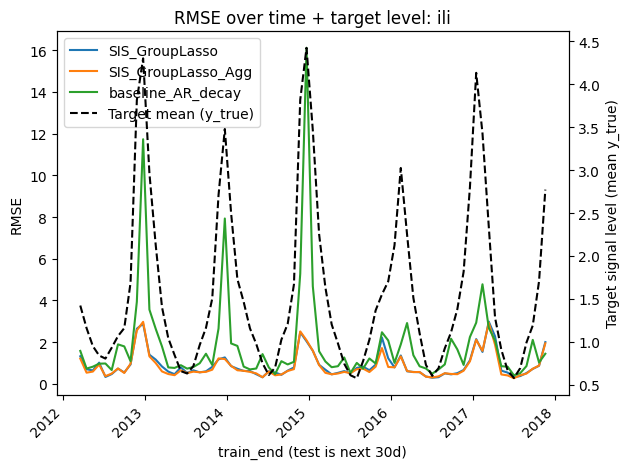

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.117341  0.612455  15300.0
1           ili  SIS_GroupLasso_Agg  1.065137  0.584175  15300.0
2           ili   baseline_AR_decay  3.047932  1.107109  15300.0
0.5


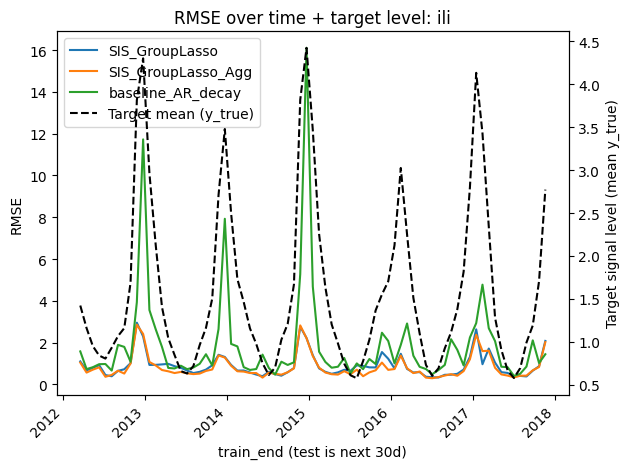

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.062611  0.627697  15300.0
1           ili  SIS_GroupLasso_Agg  1.002907  0.573125  15300.0
2           ili   baseline_AR_decay  3.047932  1.107109  15300.0
1


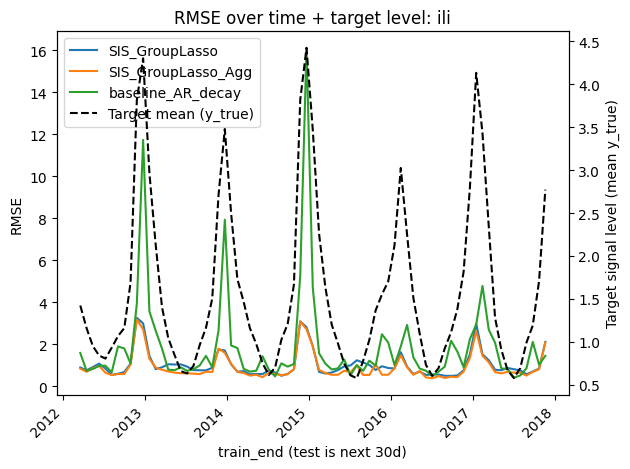

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.209289  0.751125  15300.0
1           ili  SIS_GroupLasso_Agg  1.107272  0.651914  15300.0
2           ili   baseline_AR_decay  3.047932  1.107109  15300.0
5


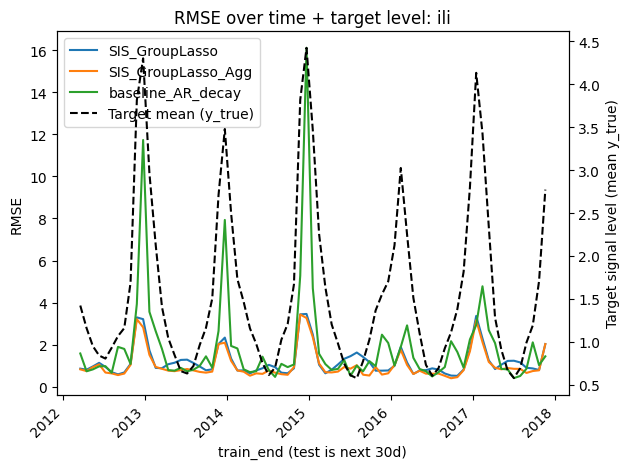

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.410696  0.923679  15300.0
1           ili  SIS_GroupLasso_Agg  1.264063  0.778171  15300.0
2           ili   baseline_AR_decay  3.047932  1.107109  15300.0


In [5]:
FEATURE_LAGS = (1, 2, 3, 4)
AR_LAGS      = (3, 4, 52, 53)
BASELINE_GAMMAS = [0.0, 0.01, 0.05, 0.1]
K_CANDIDATES = 3
S_SCREEN = 50    # top-s entries in sparsity-index screening
unit = 'W'
RETRAIN_EVERY = 4
TEST_WINDOW = 4
VAL_WINDOW = 4
TRAIN_WINDOW = 55

target_wide = target_wide.sort_index()
target_idx = pd.to_datetime(target_wide.index)
feature_wides_raw = {k: v for k, v in all_signal_wides.items() if k != target_name}
feature_wides = {}
for sig_name, wide in feature_wides_raw.items():
    if wide is None or len(wide) == 0:
        continue
    wide = wide.sort_index().copy()
    wide.index = pd.to_datetime(wide.index)
    wide_aligned = wide.reindex(target_idx)
    wide_aligned = wide_aligned.mask(wide_aligned < 0, 0.0)
    # wide_aligned = wide_aligned.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
    # wide_aligned = wide_aligned.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
    wide_aligned = wide_aligned.fillna(0.0)
    nonconstant_cols = (wide_aligned.abs().sum(axis=0) > 0)
    wide_aligned = wide_aligned.loc[:, nonconstant_cols]
    if wide_aligned.shape[1] == 0:
        continue
    feature_wides[sig_name] = wide_aligned

# Determine states common across target + (at least some) features
states = [c for c in target_wide.columns if c.isalpha() and len(c) == 2]  # typical state abbrev
states = [st for st in states if st in target_wide.columns]
if len(states) == 0:
    states = list(target_wide.columns)

train_ends = compute_walkforward_schedule(dates = target_wide.index, train_size = TRAIN_WINDOW, test_size = TEST_WINDOW, retrain_every = RETRAIN_EVERY, unit = unit)

group_size = len(FEATURE_LAGS)
assert len(AR_LAGS) == group_size, "AR_LAGS must have same length as FEATURE_LAGS for equal-size groups."

for GL_ALPHA in [0.1, 0.5, 1, 5]:
    pred_rows = []
    agg_rows = []
    for train_end in train_ends:
        train_end = pd.to_datetime(train_end)
        train_start = train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = unit)
        val_start = train_end - pd.Timedelta(VAL_WINDOW - 1, unit = unit)
        test_start = train_end + pd.Timedelta(1, unit = unit)
        test_end = train_end + pd.Timedelta(TEST_WINDOW, unit = unit)

        # Fit GroupLasso for ALL states in this window (target-only training per state)
        # Store coefs/intercepts and d = X^T y / T for candidate selection
        fit_by_state = {}
        d_by_state = {}

        # also store AR-only baseline (gamma chosen per state)
        baseline_by_state = {}

        # Pre-build datasets per state (train/val/test)
        data_cache = {}

        for st in states:
            # build full window design up to test_end so we can slice train/val/test cleanly
            built = build_design_for_state(
                target_wide, feature_wides, st,
                start_date=train_start, end_date=test_end,
                feature_lags=FEATURE_LAGS, ar_lags=AR_LAGS, unit = unit
            )
            if built is None:
                continue
            X_all, y_all, dates_all, feat_names, group_names = built
            data_cache[st] = (X_all, y_all, dates_all, feat_names, group_names)

            # indices for train/val/test within aligned dates_all
            dates_all = pd.to_datetime(dates_all)
            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)

            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ---------- Baseline: AR-only with decay gamma tuned on val ----------
            # AR columns are last len(AR_LAGS) columns by construction
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]
            best_gamma = fit_ar_baseline_decay(
                Xtr_ar, y_tr, Xva_ar, y_va, train_dates=d_tr, train_end=train_end, gammas=BASELINE_GAMMAS
            )
            baseline_by_state[st] = {"gamma": best_gamma}

            # ---------- SIS-GroupLasso fit ----------
            active_g, coef, intercept = SIS_grpLasso_KKT(
                X_expanded=X_tr, y=y_tr,
                group_size=group_size, alpha=GL_ALPHA, weights=None
            )
            fit_by_state[st] = {
                "coef": pd.Series(coef, index=feat_names),
                "intercept": intercept,
                "active_g": active_g
            }

            # d statistic for candidate selection (use training)
            d_by_state[st] = (X_tr.T @ y_tr) / max(len(y_tr), 1)

        if len(fit_by_state) < 2:
            continue

        # Now evaluate per state
        for st in list(fit_by_state.keys()):
            X_all, y_all, dates_all, feat_names, group_names = data_cache[st]
            dates_all = pd.to_datetime(dates_all)

            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)
            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ----- Baseline predictions -----
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]

            g = baseline_by_state[st]["gamma"]
            backcast_lag = (train_end - d_tr).days.astype(float).values
            w = np.exp(-g * backcast_lag)
            w = w / (w.max() if w.max() > 0 else 1.0)
            yhat_base = weighted_ols_fit_predict(Xtr_ar, y_tr, w, Xte_ar)

            # ----- SIS-GroupLasso target-only predictions -----
            target_feat_names = feat_names
            fit0 = fit_by_state[st]
            yhat_gl = predict_named(X_te, target_feat_names, fit0["coef"], fit0["intercept"])

            # ----- Aggregation -----
            # candidate states via sparsity index
            # all_states_here = [s for s in fit_by_state.keys() if s in d_by_state]
            all_states_here = [s for s in fit_by_state.keys() if s in d_by_state and s in VALID_STATES]
            cand_states = select_candidate_states(d_by_state, st, all_states_here, s=S_SCREEN, K=K_CANDIDATES)
            cand_all = [st] + cand_states

            # build Yhat on validation (on target state's X_va) and test (on target state's X_te)
            Yhat_val = []
            Yhat_test = []
            for s2 in cand_all:
                fit2 = fit_by_state[s2]
                Yhat_val.append(predict_named(X_va, target_feat_names, fit2["coef"], fit2["intercept"]))
                Yhat_test.append(predict_named(X_te, target_feat_names, fit2["coef"], fit2["intercept"]))
            Yhat_val = np.column_stack(Yhat_val)
            Yhat_test = np.column_stack(Yhat_test)

            w_agg = q_aggregate_weights(y_va, Yhat_val, total_step=10, selection=False, eps=1e-3)
            yhat_agg = Yhat_test @ w_agg
            for j, s2 in enumerate(cand_all):
                agg_rows.append({
                    "target_signal": target_name,
                    "target_state": st,
                    "train_end": train_end.date().isoformat(),
                    "candidate_state": s2,
                    "is_self": (j == 0),
                    "rank": j,                 # 0=self, 1..K are candidates
                    "weight": float(w_agg[j])  # weight for this candidate in Q-agg
                })
            for i, dt in enumerate(d_te):
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "baseline_AR_decay",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_base[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_gl[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso_Agg",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_agg[i]),
                })
    print(GL_ALPHA)
    pred_df = pd.DataFrame(pred_rows)
    agg_df = pd.DataFrame(agg_rows)
    agg_df["train_end"] = pd.to_datetime(agg_df["train_end"])
    # summary metrics
    summary = (
        pred_df.groupby(["target_signal", "model", "geo_value"])
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "N": len(g)
        }))
        .reset_index()
    )

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
    pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

    def rmse(x):
        return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))

    # A) RMSE per retrain step (each step = next 30-day test period)
    rmse_by_step = (
        pred_df
        .groupby(["target_signal", "model", "train_end"])
        .apply(rmse)
        .rename("RMSE")
        .reset_index()
        .sort_values(["target_signal", "model", "train_end"])
    )

    sig = pred_df["target_signal"].iloc[0]
    tmp = rmse_by_step[rmse_by_step["target_signal"] == sig].copy()

    # Build a "target level" series aligned to train_end:
    # use mean(y_true) over the corresponding test block (all states pooled)
    target_level = (
        pred_df[pred_df["target_signal"] == sig]
        .groupby("train_end")["y_true"]
        .mean()
        .rename("target_mean")
        .reset_index()
    )

    # Merge so x-axis aligns
    tmp2 = tmp.merge(target_level, on="train_end", how="left")

    fig, ax = plt.subplots()

    # left axis: RMSE by model
    for m, g in tmp2.groupby("model"):
        ax.plot(g["train_end"], g["RMSE"], label=m)
    ax.set_xlabel("train_end (test is next 30d)")
    ax.set_ylabel("RMSE")

    # right axis: target signal level
    ax2 = ax.twinx()
    ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
    ax2.set_ylabel("Target signal level (mean y_true)")

    # combined legend (both axes)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax.set_title(f"RMSE over time + target level: {sig}")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


    print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    })).reset_index())

    # exclude self
    cand_only = agg_df[~agg_df["is_self"]].copy()

    # frequency table
    freq = (
        cand_only
        .groupby(["target_signal", "target_state", "candidate_state"])
        .size()
        .rename("count")
        .reset_index()
    )

    from collections import defaultdict

    def most_frequent_candidates_dict(agg_df, top_k=5, drop_self=True, min_count=1):
        df = agg_df.copy()

        if drop_self and "is_self" in df.columns:
            df = df[~df["is_self"]]

        # frequency count
        freq = (
            df.groupby(["target_state", "candidate_state"])
            .size()
            .rename("count")
            .reset_index()
        )

        # filter low counts if wanted
        freq = freq[freq["count"] >= min_count]

        # build dict: state -> list of top_k candidates
        out = {}
        for st, g in freq.sort_values(["target_state", "count"], ascending=[True, False]).groupby("target_state"):
            out[st] = g["candidate_state"].head(top_k).tolist()

        return out

    # usage:
    top_candidates = most_frequent_candidates_dict(agg_df, top_k=5)
    top_candidates

In [10]:
pred_df

""


In [6]:
top_candidates

{'AK': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'AL': ['GA', 'NC', 'LA', 'VA', 'OK'],
 'AR': ['KS', 'NM', 'SC', 'WI', 'AZ'],
 'AZ': ['MN', 'MD', 'MA', 'OH', 'WI'],
 'CA': ['FL', 'NY', 'TX', 'GA', 'MD'],
 'CO': ['WA', 'KS', 'UT', 'WI', 'NM'],
 'CT': ['WI', 'MA', 'CO', 'WA', 'MN'],
 'DC': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'DE': ['WY', 'RI', 'VT', 'NH', 'SD'],
 'FL': ['IL', 'NY', 'PA', 'NJ', 'GA'],
 'GA': ['NC', 'AL', 'VA', 'LA', 'OK'],
 'HI': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'IA': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'ID': ['ME', 'NE', 'KY', 'SD', 'NV'],
 'IL': ['PA', 'VA', 'NJ', 'NC', 'NY'],
 'IN': ['MO', 'OH', 'OK', 'TN', 'WI'],
 'KS': ['NM', 'CO', 'AR', 'WA', 'UT'],
 'KY': ['ID', 'WV', 'NE', 'NV', 'OR'],
 'LA': ['MS', 'OK', 'GA', 'AL', 'NC'],
 'MA': ['MN', 'CT', 'WI', 'AZ', 'MI'],
 'MD': ['OH', 'AZ', 'MN', 'IN', 'MI'],
 'ME': ['VT', 'SD', 'DE', 'ID', 'NE'],
 'MI': ['OH', 'IN', 'MO', 'WI', 'VA'],
 'MN': ['WI', 'AZ', 'MD', 'MA', 'CT'],
 'MO': ['IN', 'TN', 'OH', 'OK', 'WI'],
 'MS': ['LA', 'OK', 'TN',

In [17]:
train_end

Timestamp('2017-11-19 00:00:00')

In [16]:
print(train_start, val_start, test_start, test_end)

2016-11-06 00:00:00 2017-10-29 00:00:00 2017-11-26 00:00:00 2017-12-17 00:00:00


In [18]:
train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = 'D')

Timestamp('2017-09-26 00:00:00')

In [19]:
train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = 'W')

Timestamp('2016-11-06 00:00:00')

In [20]:
unit

'W'

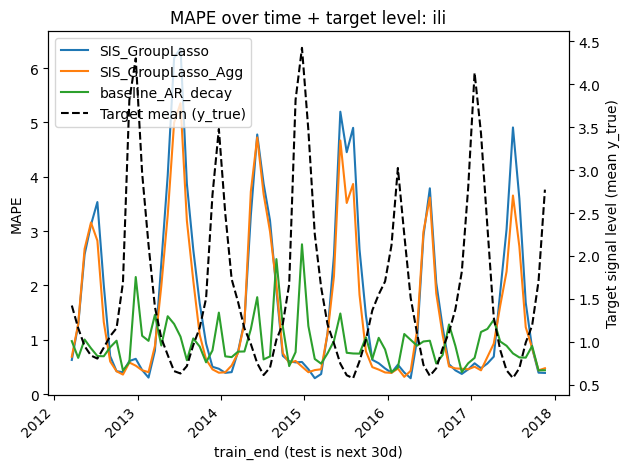

  target_signal               model      RMSE       MAE        N
0           ili      SIS_GroupLasso  1.410696  0.923679  15300.0
1           ili  SIS_GroupLasso_Agg  1.264063  0.778171  15300.0
2           ili   baseline_AR_decay  3.047932  1.107109  15300.0


{'AK': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'AL': ['GA', 'NC', 'LA', 'VA', 'OK'],
 'AR': ['KS', 'NM', 'SC', 'WI', 'AZ'],
 'AZ': ['MN', 'MD', 'MA', 'OH', 'WI'],
 'CA': ['FL', 'NY', 'TX', 'GA', 'MD'],
 'CO': ['WA', 'KS', 'UT', 'WI', 'NM'],
 'CT': ['WI', 'MA', 'CO', 'WA', 'MN'],
 'DC': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'DE': ['WY', 'RI', 'VT', 'NH', 'SD'],
 'FL': ['IL', 'NY', 'PA', 'NJ', 'GA'],
 'GA': ['NC', 'AL', 'VA', 'LA', 'OK'],
 'HI': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'IA': ['RI', 'DE', 'NH', 'VT', 'WY'],
 'ID': ['ME', 'NE', 'KY', 'SD', 'NV'],
 'IL': ['PA', 'VA', 'NJ', 'NC', 'NY'],
 'IN': ['MO', 'OH', 'OK', 'TN', 'WI'],
 'KS': ['NM', 'CO', 'AR', 'WA', 'UT'],
 'KY': ['ID', 'WV', 'NE', 'NV', 'OR'],
 'LA': ['MS', 'OK', 'GA', 'AL', 'NC'],
 'MA': ['MN', 'CT', 'WI', 'AZ', 'MI'],
 'MD': ['OH', 'AZ', 'MN', 'IN', 'MI'],
 'ME': ['VT', 'SD', 'DE', 'ID', 'NE'],
 'MI': ['OH', 'IN', 'MO', 'WI', 'VA'],
 'MN': ['WI', 'AZ', 'MD', 'MA', 'CT'],
 'MO': ['IN', 'TN', 'OH', 'OK', 'WI'],
 'MS': ['LA', 'OK', 'TN',

In [17]:
pred_df = pd.DataFrame(pred_rows)
agg_df = pd.DataFrame(agg_rows)
agg_df["train_end"] = pd.to_datetime(agg_df["train_end"])
# summary metrics
summary = (
    pred_df.groupby(["target_signal", "model", "geo_value"])
    .apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    }))
    .reset_index()
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

def rmse(x):
    return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))
def mape(x):
    y_true = x["y_true"].values
    y_pred = x["y_pred"].values

    mask = y_true != 0
    if not np.any(mask):
        return 0

    return np.mean(np.abs(1 - y_pred[mask] / y_true[mask]))

# A) RMSE per retrain step (each step = next 30-day test period)
mape_by_step = (
    pred_df
    .groupby(["target_signal", "model", "train_end"])
    .apply(mape)
    .rename("MAPE")
    .reset_index()
    .sort_values(["target_signal", "model", "train_end"])
)

sig = pred_df["target_signal"].iloc[0]
tmp = mape_by_step[mape_by_step["target_signal"] == sig].copy()

# Build a "target level" series aligned to train_end:
# use mean(y_true) over the corresponding test block (all states pooled)
target_level = (
    pred_df[pred_df["target_signal"] == sig]
    .groupby("train_end")["y_true"]
    .mean()
    .rename("target_mean")
    .reset_index()
)

# Merge so x-axis aligns
tmp2 = tmp.merge(target_level, on="train_end", how="left")

fig, ax = plt.subplots()

# left axis: MAPE by model
for m, g in tmp2.groupby("model"):
    ax.plot(g["train_end"], g["MAPE"], label=m)
ax.set_xlabel("train_end (test is next 30d)")
ax.set_ylabel("MAPE")

# right axis: target signal level
ax2 = ax.twinx()
ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
ax2.set_ylabel("Target signal level (mean y_true)")

# combined legend (both axes)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax.set_title(f"MAPE over time + target level: {sig}")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
    "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
    "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
    "N": len(g)
})).reset_index())

# exclude self
cand_only = agg_df[~agg_df["is_self"]].copy()

# frequency table
freq = (
    cand_only
    .groupby(["target_signal", "target_state", "candidate_state"])
    .size()
    .rename("count")
    .reset_index()
)

from collections import defaultdict

def most_frequent_candidates_dict(agg_df, top_k=5, drop_self=True, min_count=1):
    df = agg_df.copy()

    if drop_self and "is_self" in df.columns:
        df = df[~df["is_self"]]

    # frequency count
    freq = (
        df.groupby(["target_state", "candidate_state"])
          .size()
          .rename("count")
          .reset_index()
    )

    # filter low counts if wanted
    freq = freq[freq["count"] >= min_count]

    # build dict: state -> list of top_k candidates
    out = {}
    for st, g in freq.sort_values(["target_state", "count"], ascending=[True, False]).groupby("target_state"):
        out[st] = g["candidate_state"].head(top_k).tolist()

    return out

# usage:
top_candidates = most_frequent_candidates_dict(agg_df, top_k=5)
top_candidates

/tmp/ipykernel_823123/2968602586.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


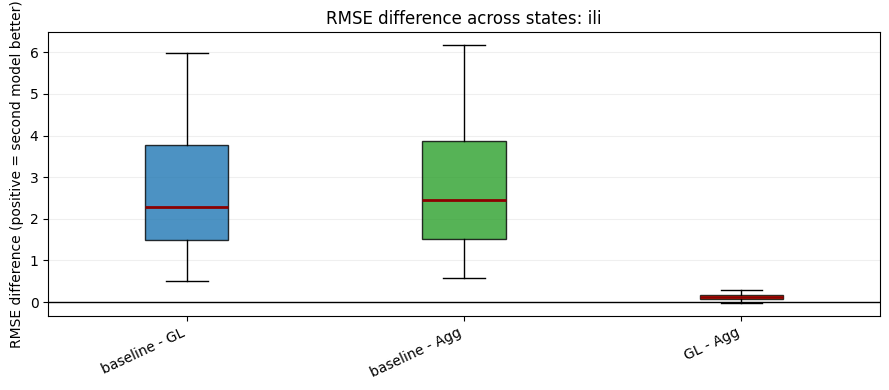

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sig = pred_df["target_signal"].iloc[0]
df_sig = pred_df[pred_df["target_signal"] == sig].copy()

# per-state RMSE for each model (across ALL test points in pred_df)
rmse_state = (
    df_sig.groupby(["geo_value", "model"])
    .apply(lambda g: np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
    .rename("RMSE")
    .reset_index()
)

# wide: rows=state, cols=model
rmse_wide = rmse_state.pivot(index="geo_value", columns="model", values="RMSE")

# choose your model names
BASE = "baseline_AR_decay"
GL   = "SIS_GroupLasso"
AGG  = "SIS_GroupLasso_Agg"

# keep only states with all models present
rmse_wide = rmse_wide[[BASE, GL, AGG]].dropna()

# differences (positive means SECOND is better if you do base - other? depends)
diff_df = pd.DataFrame(index=rmse_wide.index)
diff_df["baseline - GL"]  = rmse_wide[BASE] - rmse_wide[GL]
diff_df["baseline - Agg"] = rmse_wide[BASE] - rmse_wide[AGG]
diff_df["GL - Agg"]       = rmse_wide[GL]   - rmse_wide[AGG]

def get_base_diff(colname: str):
    # here each column is already a base diff label
    return colname

base_diff_to_color = {
    "baseline - GL":  "tab:blue",
    "baseline - Agg": "tab:green",
    "GL - Agg":       "tab:orange",
}

def color_boxes_by_diff(ax, bp, columns):
    for i, box_artist in enumerate(bp["boxes"]):
        colname = columns[i]
        color = base_diff_to_color.get(colname, "lightgray")
        box_artist.set_facecolor(color)
        box_artist.set_edgecolor("black")
        box_artist.set_alpha(0.8)

    for w in bp["whiskers"]:
        w.set(color="black", linewidth=1)
    for c in bp["caps"]:
        c.set(color="black", linewidth=1)
    for m in bp["medians"]:
        m.set(color="darkred", linewidth=2)

# Plot
cols = diff_df.columns.tolist()

fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    [diff_df[c].values for c in cols],
    labels=cols,
    patch_artist=True,
    showfliers=False
)

color_boxes_by_diff(ax, bp, cols)

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("RMSE difference (positive = second model better)")
ax.set_title(f"RMSE difference across states: {sig}")
ax.grid(True, axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
